# Stage 3 ABM — Diagnostic Analysis

LOB + ZI + Chiarella FT/MT + BCM/NBCM clearing tier with client books.

This notebook runs a fresh Stage 3 simulation, captures per-agent state at every step, and visualises:
1. Mid-price vs fundamental V_t
2. Spread evolution and distribution
3. Order book depth (bid/ask)
4. EWMA momentum signal
5. Per-step volume
6. Return stylised facts (Cont 2001): distribution, ACF(r), ACF(|r|)
7. Agent-level inventory and cash by type
8. CM capital ratios over time (BCMs with vs without clients; NBCMs)


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from model.globals import ModelParams
from model.simulation import Simulation
from model.agents import (
    ZeroIntelligenceTrader, FundamentalTrader, MomentumTrader,
    BankingClearingMember, NonBankingClearingMember,
)
from run_simulation import build_traders

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

params = ModelParams(
    n_zi=10, n_fundamental=0, n_momentum=0,
    n_bcm=10, n_nbcm=10, n_bcm_with_clients=3,
    v0=450.0, tick_size=0.01, dt_minutes=5.0, order_ttl=2,
    zi_alpha=0.15, zi_mu=0.025, zi_delta=0.025,
    zi_qty_min=1, zi_qty_max=10, zi_offset_max=5,
    ft_sigma=0.5,
    mt_sigma=0.5, mt_lambda_ewma=0.95, mt_threshold=1e-4,
    mu_v=0.0, sigma_v=0.001,
    jump_lambda=0.0, jump_mean=0.0, jump_std=0.01,
)

# Run sim and snapshot per-agent state at every step
N_STEPS = 78 * 5   # 5 trading days
traders = build_traders(params, seed=42)
sim = Simulation(params, traders, seed=42)

agent_inv = defaultdict(list)   # agent_id -> [inv_t for t in 0..N-1]
agent_cash = defaultdict(list)
for _ in range(N_STEPS):
    sim.step()
    for t in sim.traders:
        agent_inv[t.agent_id].append(t.inventory)
        agent_cash[t.agent_id].append(t.cash)

df = pd.DataFrame(sim.history)
df['log_ret'] = np.log(df['mid_price']).diff()
print(f'steps simulated      : {len(df)}')
print(f'agents               : {len(traders)}')
print(f'final mid            : {df["mid_price"].iloc[-1]:.4f}')
print(f'final V              : {df["fundamental"].iloc[-1]:.4f}')
print(f'total volume         : {int(df["volume"].sum())}')
print(f'corr(mid, V)         : {df[["mid_price","fundamental"]].corr().iloc[0,1]:.4f}')


steps simulated      : 390
agents               : 69
final mid            : 448.9900
final V              : 448.7154
total volume         : 25179
corr(mid, V)         : 0.9905


## 1. Mid-price vs fundamental V_t

V is generated exogenously by the Merton (1976) jump-diffusion process in `GlobalState.step`. With FT and BCM populations placing limits at `V + z·σ_F`, mid-price should track V tightly. A breakdown here would indicate that the market-clearing layer isn't properly anchored to the fundamental signal.

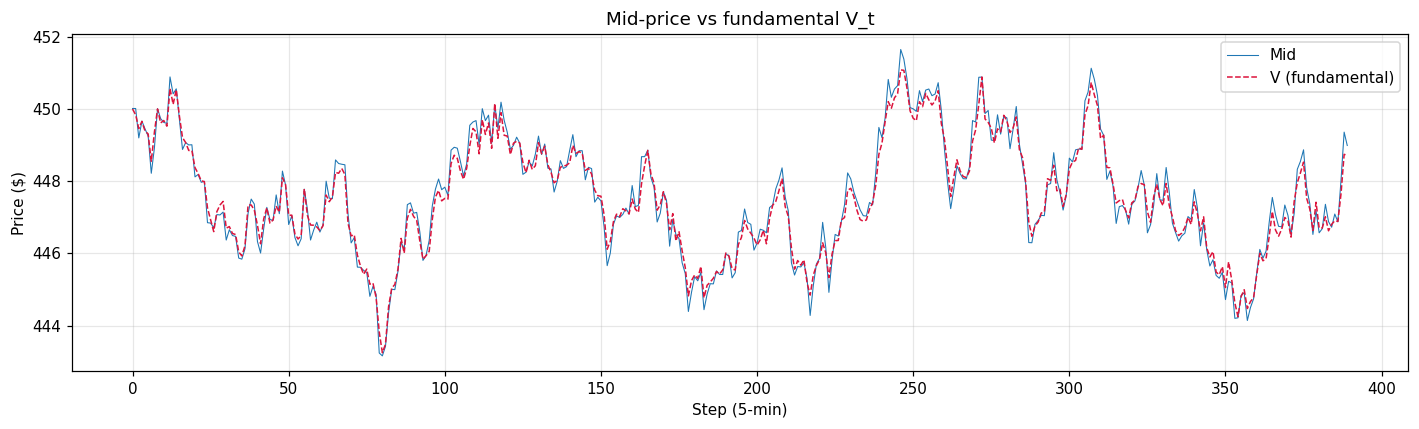

mispricing mean=+0.0356  std=0.2439  abs-max=0.7474


In [38]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['t'], df['mid_price'], lw=0.7, label='Mid')
ax.plot(df['t'], df['fundamental'], lw=1.0, ls='--', color='crimson', label='V (fundamental)')
ax.set_xlabel('Step (5-min)'); ax.set_ylabel('Price ($)')
ax.set_title('Mid-price vs fundamental V_t')
ax.legend(); plt.tight_layout(); plt.show()

mispricing = df['mid_price'] - df['fundamental']
print(f'mispricing mean={mispricing.mean():+.4f}  std={mispricing.std():.4f}  abs-max={mispricing.abs().max():.4f}')


## 2. Spread evolution and distribution

Spread emerges from the gap between best bid and best ask after the call auction. With FT/BCM placement at V±z·σ_F, the spread distribution has a heavier tail than pure ZI flow because z occasionally takes large values. p99 should remain bounded; max can widen transiently when both deep-z bids and asks survive simultaneously.

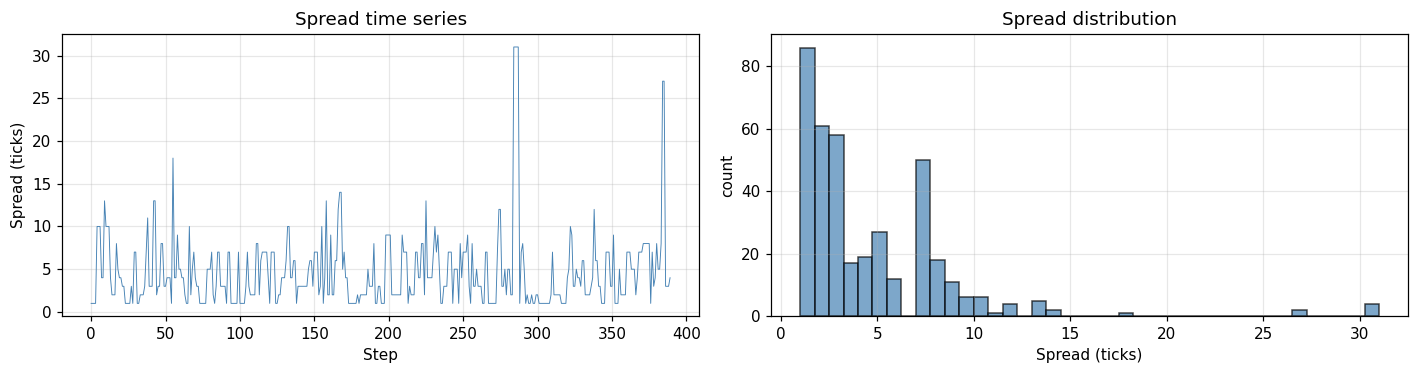

spread (ticks): mean=4.60  p50=3  p99=27  max=31


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
sp_ticks = df['spread'] / params.tick_size
axes[0].plot(df['t'], sp_ticks, lw=0.6, color='steelblue')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Spread (ticks)'); axes[0].set_title('Spread time series')
axes[1].hist(sp_ticks.dropna(), bins=40, color='steelblue', edgecolor='k', alpha=0.7)
axes[1].set_xlabel('Spread (ticks)'); axes[1].set_ylabel('count'); axes[1].set_title('Spread distribution')
plt.tight_layout(); plt.show()

print(f'spread (ticks): mean={sp_ticks.mean():.2f}  p50={sp_ticks.median():.0f}  p99={sp_ticks.quantile(0.99):.0f}  max={sp_ticks.max():.0f}')


## 3. Order book depth

Bid and ask depth should be roughly balanced under symmetric flow (Farmer et al. 2005). Persistent asymmetry would indicate one trader-type dominates one side.

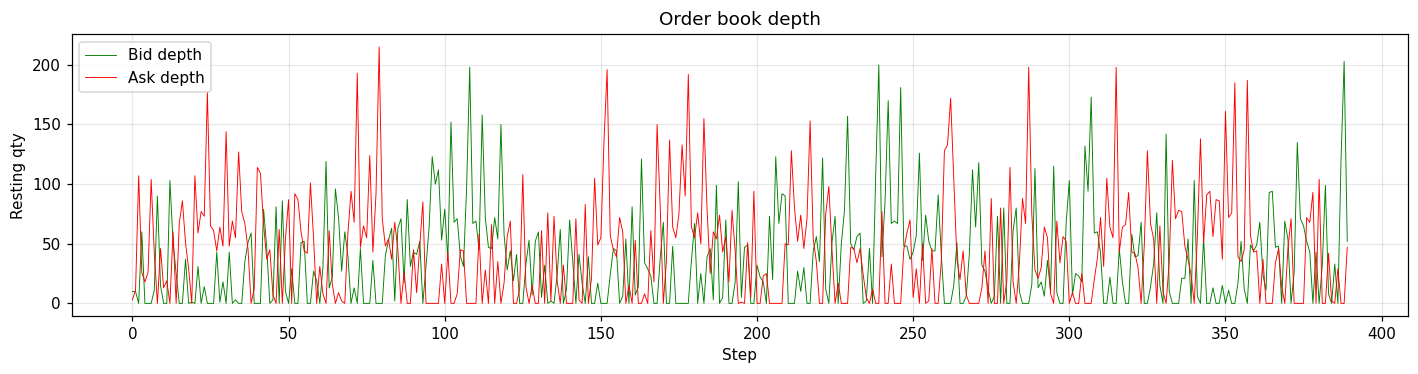

bid depth: mean=36.30  ask depth: mean=43.35


In [40]:
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(df['t'], df['bid_depth'], lw=0.6, color='green', label='Bid depth')
ax.plot(df['t'], df['ask_depth'], lw=0.6, color='red', label='Ask depth')
ax.set_xlabel('Step'); ax.set_ylabel('Resting qty')
ax.set_title('Order book depth')
ax.legend(); plt.tight_layout(); plt.show()

print(f'bid depth: mean={df["bid_depth"].mean():.2f}  ask depth: mean={df["ask_depth"].mean():.2f}')


## 4. EWMA momentum signal

`M_t = λ·M_{t-1} + (1-λ)·(log P_t - log P_{t-1})` with λ = 0.95. MT direction follows sign(M_t). Under random V drift, M_t fluctuates around 0; under a trending V, it should develop persistent sign.

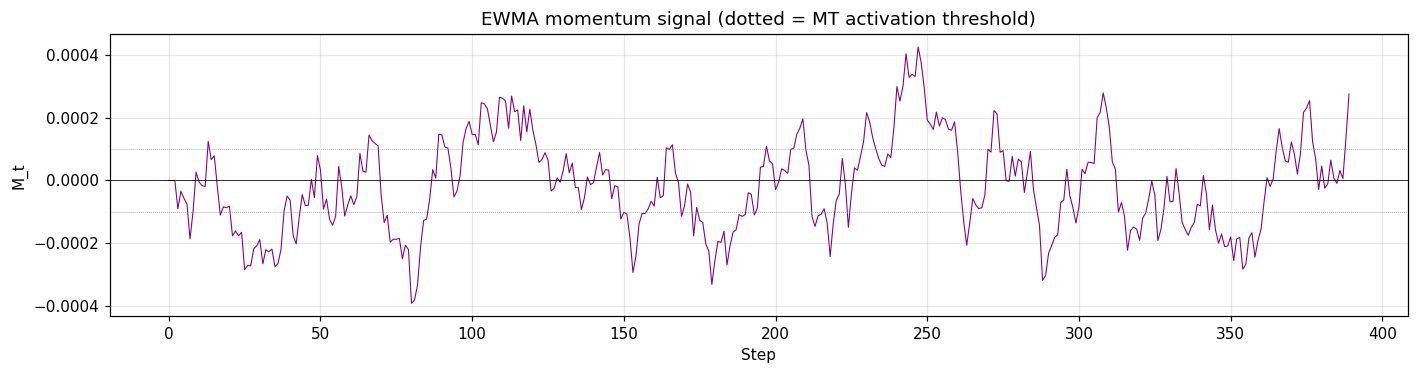

fraction of steps where MT would fire (|M| > threshold): 52.6%


In [41]:
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(df['t'], df['momentum'], lw=0.7, color='purple')
ax.axhline(0, color='k', lw=0.5)
ax.axhline(params.mt_threshold, color='gray', lw=0.5, ls=':')
ax.axhline(-params.mt_threshold, color='gray', lw=0.5, ls=':')
ax.set_xlabel('Step'); ax.set_ylabel('M_t')
ax.set_title('EWMA momentum signal (dotted = MT activation threshold)')
plt.tight_layout(); plt.show()

active_frac = (df['momentum'].abs() > params.mt_threshold).mean()
print(f'fraction of steps where MT would fire (|M| > threshold): {active_frac*100:.1f}%')


## 5. Per-step volume

ZI-only Stage 1 gave ~4.5% of steps with fills; FT/BCM activity at Stage 3 typically pushes this above 90%.

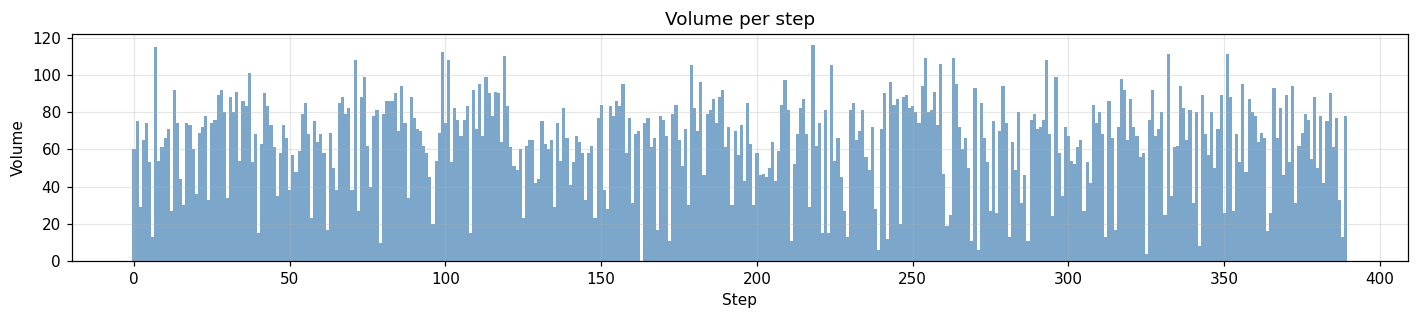

total volume: 25179  filling steps: 99.7%


In [42]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(df['t'], df['volume'], width=1, color='steelblue', alpha=0.7)
ax.set_xlabel('Step'); ax.set_ylabel('Volume')
ax.set_title('Volume per step')
plt.tight_layout(); plt.show()

print(f'total volume: {int(df["volume"].sum())}  filling steps: {(df["volume"]>0).mean()*100:.1f}%')


## 6. Return stylised facts (Cont 2001)

Three established facts:
- Fact #1: ACF of raw returns near zero at all lags > 0
- Fact #2: heavy-tailed return distribution (excess kurtosis > 0)
- Fact #3: ACF of |returns| positive and slowly decaying (volatility clustering)

Stage 1 ZI-only typically shows fact #1 at lag 1 negative (Roll 1984 bid-ask bounce); fact #3 only emerges with sufficient MT activity, which depends on calibration of σ_F vs σ_M (Stage 8).

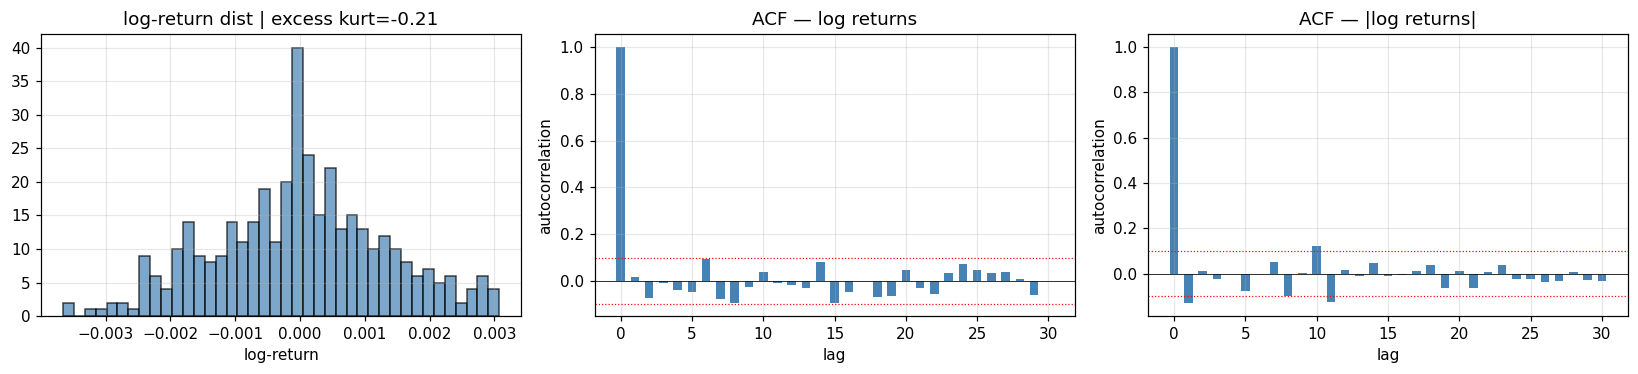

log-return: std=1.3295e-03  excess kurtosis=-0.21
ACF(r,1)   = +0.016   (Cont fact #1 target: ~0)
ACF(|r|,1) = -0.131   (Cont fact #3 target: > 0)


In [43]:
def acf_series(x, lags):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    var = (x * x).sum()
    return [1.0] + [(x[:-k] * x[k:]).sum() / var for k in range(1, lags + 1)]

rets = df['log_ret'].dropna()
lags = 30
acf_r = acf_series(rets.values, lags)
acf_abs = acf_series(rets.abs().values, lags)
ks = np.arange(lags + 1)
ci_95 = 1.96 / np.sqrt(len(rets))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].hist(rets, bins=40, color='steelblue', edgecolor='k', alpha=0.7)
axes[0].set_title(f'log-return dist | excess kurt={rets.kurtosis():.2f}')
axes[0].set_xlabel('log-return')

for ax, vals, label in [(axes[1], acf_r, 'log returns'), (axes[2], acf_abs, '|log returns|')]:
    ax.bar(ks, vals, width=0.6, color='steelblue')
    ax.axhline(ci_95, color='red', ls=':', lw=0.8)
    ax.axhline(-ci_95, color='red', ls=':', lw=0.8)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('lag'); ax.set_ylabel('autocorrelation')
    ax.set_title(f'ACF — {label}')

plt.tight_layout(); plt.show()

print(f'log-return: std={rets.std():.4e}  excess kurtosis={rets.kurtosis():.2f}')
print(f'ACF(r,1)   = {acf_r[1]:+.3f}   (Cont fact #1 target: ~0)')
print(f'ACF(|r|,1) = {acf_abs[1]:+.3f}   (Cont fact #3 target: > 0)')


## 7. Agent-level state at end of run

Inventory and cash trajectories, grouped by agent type. Direct ZIs typically end with mean inventory ≈ 0; FT/BCM clients accumulate persistent positions because their reservation is biased by their fixed `z_score`. NBCM inventory is exactly zero by construction.

                          count  inv_mean  inv_std  inv_min  inv_max
BankingClearingMember        10   -233.10  1420.66    -1795     1570
FundamentalTrader            13    270.54  1206.85    -1730     2002
MomentumTrader               13    -64.46   415.57     -642      450
NonBankingClearingMember     10      0.00     0.00        0        0
ZeroIntelligenceTrader       23    -15.13    45.05      -92      105

Total inventory across all agents (should be 0): 0


/var/folders/n1/hz9fp9dj5wd300076k89wf200000gp/T/ipykernel_44573/794482852.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_inv, labels=[t[:6] for t in type_order])
/var/folders/n1/hz9fp9dj5wd300076k89wf200000gp/T/ipykernel_44573/794482852.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_cash, labels=[t[:6] for t in type_order])


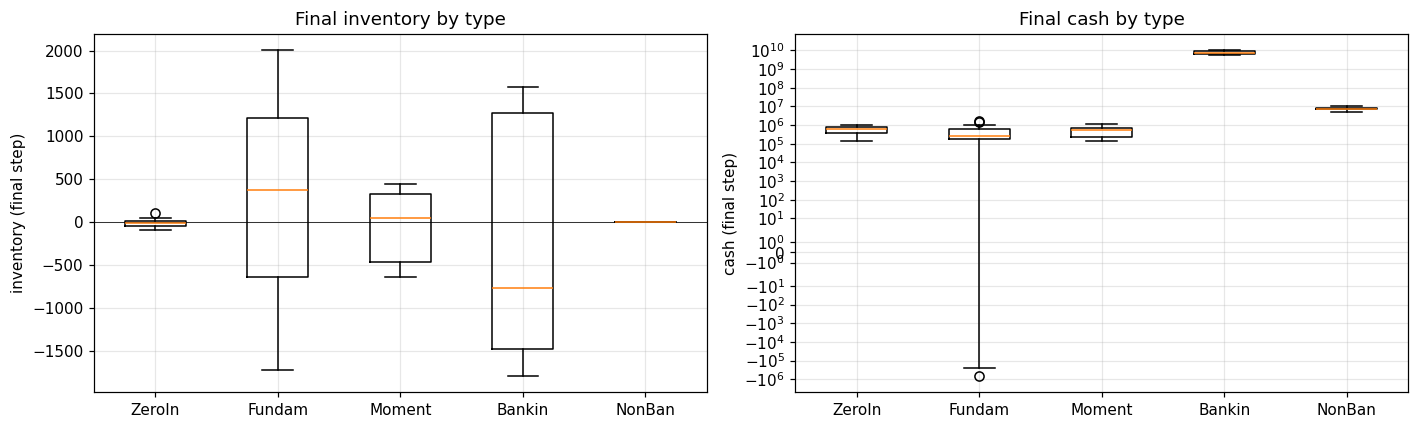

In [44]:
inv = pd.DataFrame(agent_inv).T
cash = pd.DataFrame(agent_cash).T
inv.columns = [f't{c}' for c in inv.columns]
cash.columns = [f't{c}' for c in cash.columns]
inv.index.name = 'agent_id'
cash.index.name = 'agent_id'

types = {t.agent_id: type(t).__name__ for t in traders}
inv['type'] = inv.index.map(types)
cash['type'] = cash.index.map(types)

# per-type summary at end of run
final_inv = inv.iloc[:, -2]   # last column before 'type'
final_cash = cash.iloc[:, -2]
summary = pd.DataFrame({
    'count': inv.groupby('type').size(),
    'inv_mean': final_inv.groupby(types).mean(),
    'inv_std': final_inv.groupby(types).std(),
    'inv_min': final_inv.groupby(types).min(),
    'inv_max': final_inv.groupby(types).max(),
})
print(summary.round(2))
print(f'\nTotal inventory across all agents (should be 0): {final_inv.sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
type_order = ['ZeroIntelligenceTrader', 'FundamentalTrader', 'MomentumTrader',
              'BankingClearingMember', 'NonBankingClearingMember']
data_inv  = [final_inv[final_inv.index.map(lambda i: types[i] == tn)].values for tn in type_order]
data_cash = [final_cash[final_cash.index.map(lambda i: types[i] == tn)].values for tn in type_order]
axes[0].boxplot(data_inv, labels=[t[:6] for t in type_order])
axes[0].set_ylabel('inventory (final step)'); axes[0].set_title('Final inventory by type')
axes[0].axhline(0, color='k', lw=0.5)
axes[1].boxplot(data_cash, labels=[t[:6] for t in type_order])
axes[1].set_ylabel('cash (final step)'); axes[1].set_title('Final cash by type')
axes[1].set_yscale('symlog')
plt.tight_layout(); plt.show()


## 8. CM capital ratios over time

Per ODD §Mech #2: cap_ratio = cash / |tradePosition|·mid. For BCMs we aggregate own + client inventory; for NBCMs we use clients only. Cap-ratio breach ≤ 8% triggers fire-sale (BCM) or stop-out (NBCM, enforced at Stage 4).

In a calm-regime baseline these ratios should stay astronomically high (BCM cash is in the billions vs inventory worth thousands). The breach scenario emerges in Stage 6 with stressed data.

/var/folders/n1/hz9fp9dj5wd300076k89wf200000gp/T/ipykernel_44573/4219005639.py:15: RuntimeWarning: divide by zero encountered in divide
  cap = np.where(notional > 0, cm_cash / notional, np.inf)


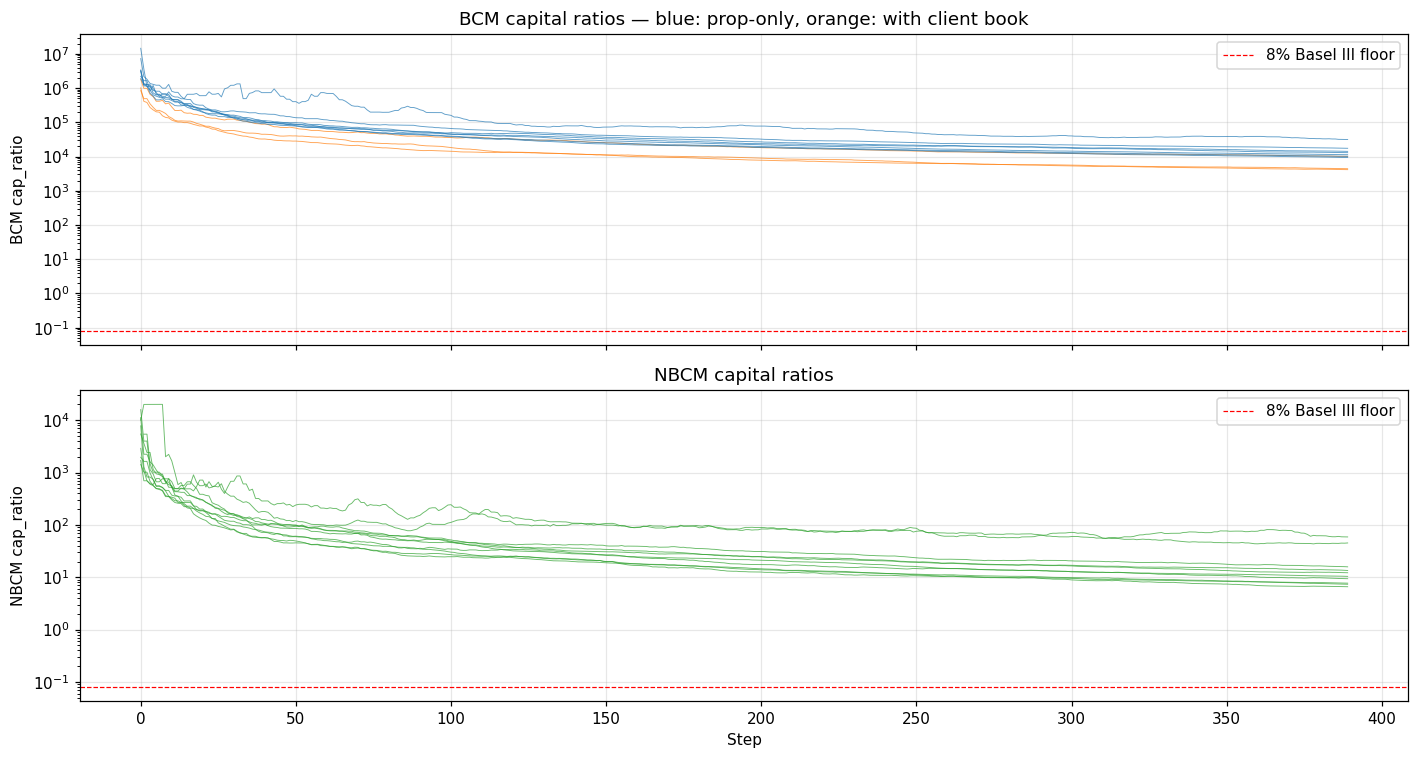

CMs that breached 8% at any point: 0
Min cap ratio per CM (sample):
   10  BankingCle  clients=3  min_cap_ratio=4.16e+03
   14  BankingCle  clients=3  min_cap_ratio=4.43e+03
   18  BankingCle  clients=3  min_cap_ratio=1.02e+04
   22  BankingCle  clients=0  min_cap_ratio=1.75e+04
   23  BankingCle  clients=0  min_cap_ratio=1.30e+04


In [45]:
# Reconstruct cap_ratio per CM at each step from recorded inventory + cash
cm_traders = [t for t in traders if isinstance(t, (BankingClearingMember, NonBankingClearingMember))]
mid_arr = df['mid_price'].ffill().fillna(params.v0).values
cap_ratio = {}
for cm in cm_traders:
    own_inv = np.array(agent_inv[cm.agent_id], dtype=float)
    client_inv = np.zeros_like(own_inv, dtype=float)
    for cid in cm.client_ids:
        client_inv += np.abs(np.array(agent_inv[cid], dtype=float))
    cm_cash = np.array(agent_cash[cm.agent_id], dtype=float)
    if isinstance(cm, BankingClearingMember):
        notional = (np.abs(own_inv) + client_inv) * mid_arr
    else:
        notional = client_inv * mid_arr
    cap = np.where(notional > 0, cm_cash / notional, np.inf)
    cap_ratio[cm.agent_id] = (type(cm).__name__, len(cm.client_ids), cap)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for aid, (tname, n_clients, cap) in cap_ratio.items():
    cap_clip = np.where(np.isinf(cap), np.nan, cap)
    if tname == 'BankingClearingMember':
        color = 'tab:blue' if n_clients == 0 else 'tab:orange'
        axes[0].plot(df['t'], cap_clip, lw=0.6, color=color, alpha=0.7)
    else:
        axes[1].plot(df['t'], cap_clip, lw=0.6, color='tab:green', alpha=0.7)

axes[0].axhline(0.08, color='red', ls='--', lw=0.8, label='8% Basel III floor')
axes[0].set_yscale('log'); axes[0].set_ylabel('BCM cap_ratio')
axes[0].set_title('BCM capital ratios — blue: prop-only, orange: with client book')
axes[0].legend()
axes[1].axhline(0.08, color='red', ls='--', lw=0.8, label='8% Basel III floor')
axes[1].set_yscale('log'); axes[1].set_ylabel('NBCM cap_ratio')
axes[1].set_title('NBCM capital ratios')
axes[1].set_xlabel('Step')
axes[1].legend()
plt.tight_layout(); plt.show()

# Min cap ratio across the run
min_caps = {aid: (t, n, np.nanmin(np.where(np.isinf(c), np.nan, c))) for aid, (t, n, c) in cap_ratio.items()}
breached = [aid for aid, (t, n, mc) in min_caps.items() if mc <= 0.08]
print(f'CMs that breached 8% at any point: {len(breached)}')
print('Min cap ratio per CM (sample):')
for aid, (tname, n, mc) in list(min_caps.items())[:5]:
    print(f'  {aid:3d}  {tname[:10]:10}  clients={n}  min_cap_ratio={mc:.2e}')


## 9. Sample agent trajectories

Five randomly chosen agents per type — visual sanity check on whether each agent type has the expected trading dynamics.

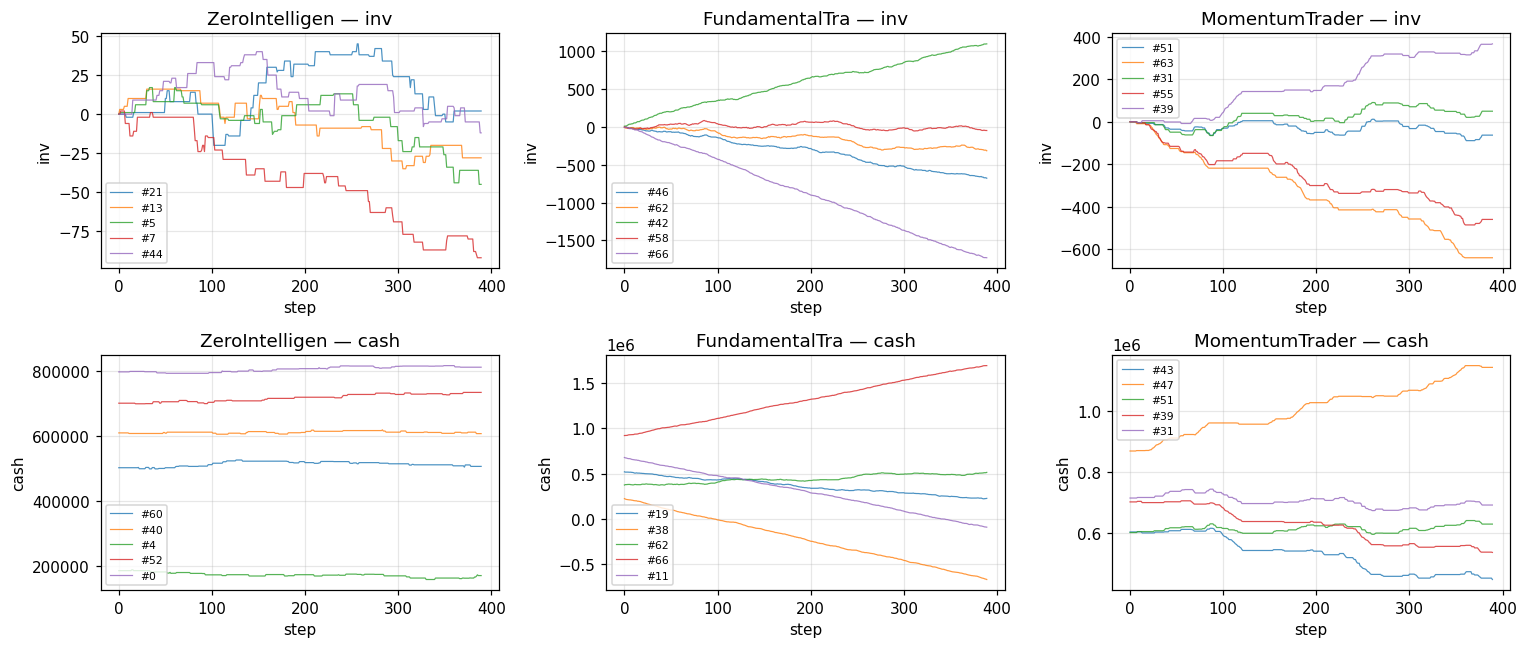

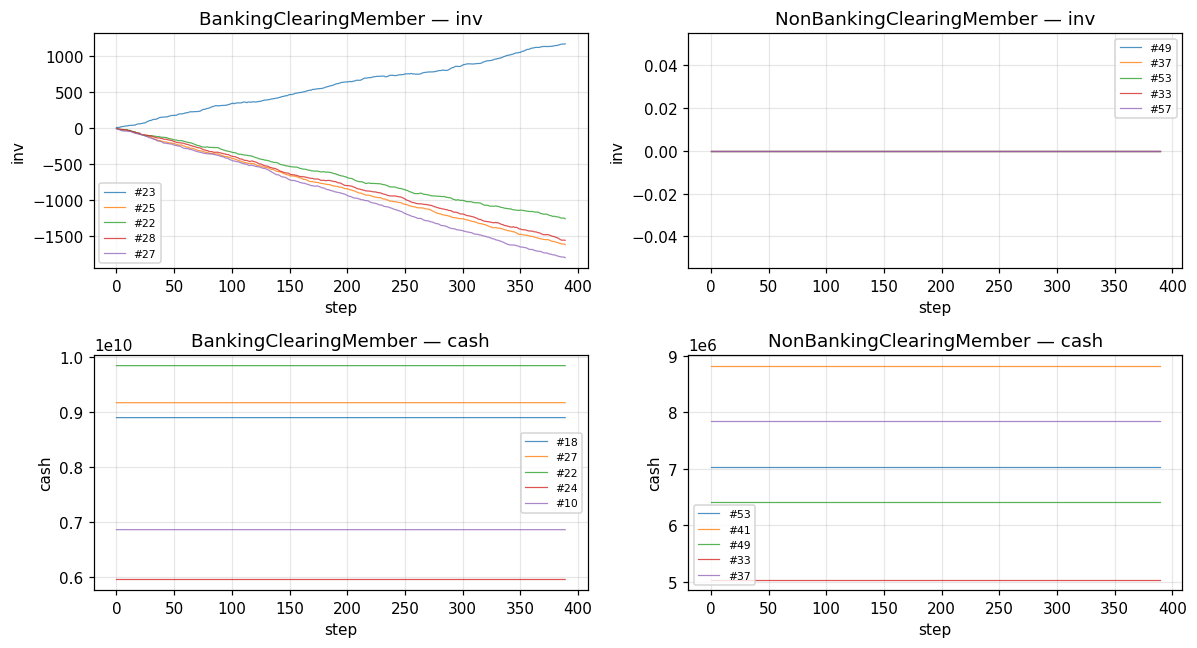

In [46]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
type_order_short = ['ZeroIntelligenceTrader', 'FundamentalTrader', 'MomentumTrader',
                    'BankingClearingMember', 'NonBankingClearingMember']
for ax_row, key in zip([axes[0], axes[1]], ['inv', 'cash']):
    for ax, tname in zip(ax_row, type_order_short[:3]):
        members = [aid for aid, t in types.items() if t == tname]
        if not members:
            ax.set_visible(False); continue
        sample = rng.choice(members, size=min(5, len(members)), replace=False)
        for aid in sample:
            series = (agent_inv if key == 'inv' else agent_cash)[aid]
            ax.plot(series, lw=0.8, alpha=0.8, label=f'#{aid}')
        ax.set_title(f'{tname[:14]} — {key}')
        ax.set_xlabel('step'); ax.set_ylabel(key)
        ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# Same plot for CMs
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax_row, key in zip([axes[0], axes[1]], ['inv', 'cash']):
    for ax, tname in zip(ax_row, type_order_short[3:]):
        members = [aid for aid, t in types.items() if t == tname]
        sample = rng.choice(members, size=min(5, len(members)), replace=False)
        for aid in sample:
            series = (agent_inv if key == 'inv' else agent_cash)[aid]
            ax.plot(series, lw=0.8, alpha=0.8, label=f'#{aid}')
        ax.set_title(f'{tname} — {key}')
        ax.set_xlabel('step'); ax.set_ylabel(key)
        ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
